--- Calculated 95% Confidence Intervals ---
  group  conversion_rate  ci_lower  ci_upper
control         0.114908  0.111139  0.118676
variant         0.141683  0.137560  0.145805 



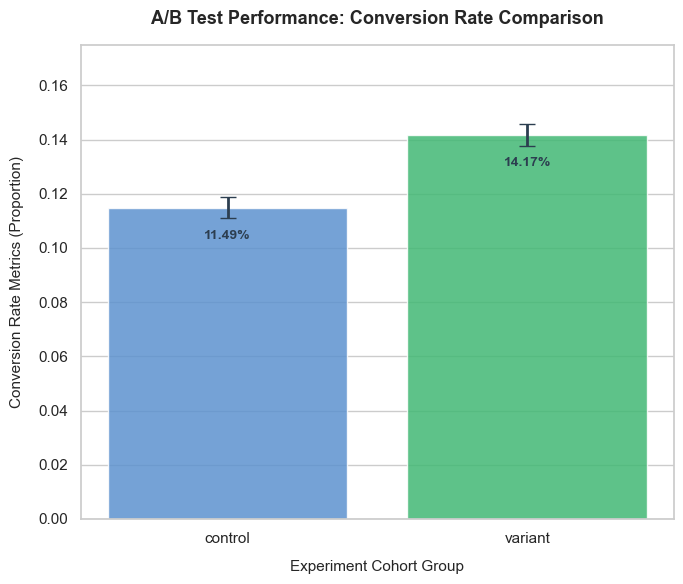

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.api as sms

# 1. Compute 95% Confidence Intervals for both cohorts
# Control Group CI
ci_control_low, ci_control_upp = sms.proportion_confint(
    count=metrics.loc[metrics['group'] == 'control', 'total_conversions'].values[0],
    nobs=metrics.loc[metrics['group'] == 'control', 'total_sessions'].values[0],
    alpha=0.05
)

# Variant Group CI
ci_variant_low, ci_variant_upp = sms.proportion_confint(
    count=metrics.loc[metrics['group'] == 'variant', 'total_conversions'].values[0],
    nobs=metrics.loc[metrics['group'] == 'variant', 'total_sessions'].values[0],
    alpha=0.05
)

# Add CI limits back into our metrics summary dataframe for visualization plotting
metrics['ci_lower'] = [ci_control_low, ci_variant_low]
metrics['ci_upper'] = [ci_control_upp, ci_variant_upp]
metrics['yerr_lower'] = metrics['conversion_rate'] - metrics['ci_lower']
metrics['yerr_upper'] = metrics['ci_upper'] - metrics['conversion_rate']

print("--- Calculated 95% Confidence Intervals ---")
print(metrics[['group', 'conversion_rate', 'ci_lower', 'ci_upper']].to_string(index=False), "\n")

# 2. Seaborn & Matplotlib Visualization Layer
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 6))

# Plot the main bar chart
ax = sns.barplot(
    data=metrics, 
    x='group', 
    y='conversion_rate', 
    hue='group',
    palette=['#4A90E2', '#2ECC71'], 
    alpha=0.85,
    legend=False
)

# Add standard error bars manually using calculated binomial confidence intervals
plt.errorbar(
    x=metrics['group'], 
    y=metrics['conversion_rate'], 
    yerr=[metrics['yerr_lower'], metrics['yerr_upper']], 
    fmt='none', 
    c='#2C3E50', 
    capsize=6, 
    linewidth=2,
    label='95% Confidence Interval'
)

# Formatting polish
plt.title('A/B Test Performance: Conversion Rate Comparison', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Experiment Cohort Group', fontsize=11, labelpad=10)
plt.ylabel('Conversion Rate Metrics (Proportion)', fontsize=11, labelpad=10)
plt.ylim(0, max(metrics['ci_upper']) * 1.2) # Dynamic top margin padding

# Value labels on top of the bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height()*100:.2f}%", 
        (p.get_x() + p.get_width() / 2., p.get_height() - 0.015), 
        ha='center', 
        va='center', 
        xytext=(0, 9), 
        textcoords='offset points', 
        fontsize=10, 
        fontweight='bold',
        color='#2C3E50'
    )

plt.tight_layout()
plt.show()